<a href="https://colab.research.google.com/github/Mbaiornom/Essai/blob/main/practical1_1_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep learning - Practical session 1.1

In our practical sessions, we will use [PyTorch](https://pytorch.org) and other libraries in its ecosystem.

The aim of this notebook is to get you started with PyTorch. At the end of this notebook, you should be able to
* work with **PyTorch Tensors**,
* specify how **your data are accessed**,
* **build a neural network**,
* **train** and **evaluate** your network.

The content in this notebook is based on the [tutorials](https://pytorch.org/tutorials/) available on the [PyTorch](https://pytorch.org) website.

## Dir pour directory permet d'inspecter des elements

--- tensorflow  est plus adapté pour les travaux de machine learning: compile automatiquement les graphes computationnels et les definiot de maniere statique

--- torch est plus recent, plus specifique mais moins specifique

---keras simplifie l'utilisation de tensorflow qui est basé sur C++

--- GPU est lié à la carte graphique

--- graphe computationnel est le graphe qui contient toutes les etapes de calcul



In [3]:
A=7
dir(A)
print(len(dir(A)))

72


In [17]:
from genericpath import getsize
import torch
import numpy as np
import sys
from sys import getsizeof

## PyTorch Tensors

_PyTorch Tensors_ (or simply tensors) are a specialized data structure that are very **similar to arrays and matrices**. In PyTorch, tensors are used to encode the **inputs** and **outputs** of a model, as well as the model's **parameters**.

Tensors are similar to NumPy's ndarrays, except that tensors **can run on GPUs** or other hardware accelerators. Tensors and NumPy arrays can share the same underlying memory, eliminating the need to copy data. Tensors are also optimized for **automatic differentiation**. If you’re familiar with NumPy's ndarrays, you’ll be at ease with tensors.

### Initializing a tensor

In [18]:
# Directly from (Python) data
data = [[1, 2],
        [3, 4]]
x_data = torch.tensor(data)
x_data

tensor([[1, 2],
        [3, 4]])

In [20]:
# From a NumPy array
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
x_np

tensor([[1, 2],
        [3, 4]])

In [21]:
# From another tensor
x_ones = torch.ones_like(x_data)
x_ones

tensor([[1, 1],
        [1, 1]])

In [23]:
# With random or constant values: ces cellules permettent de specifier les données en torch sont des tenseurs: c'est le format de pytorch

shape = (2, 3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.5030, 0.8886, 0.7487],
        [0.3791, 0.5863, 0.8429]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Attributes of a tensor

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [24]:
tensor = torch.rand(2, 2)

print(f"Shape of tensor: {tensor.shape}")
print(f"Device tensor is stored on: {tensor.device}")
print(f"Datatype of tensor: {tensor.dtype}\n")

print(f"Datatype of x_np: {x_np.dtype}")

Shape of tensor: torch.Size([2, 2])
Device tensor is stored on: cpu
Datatype of tensor: torch.float32

Datatype of x_np: torch.int64


**Note**: if you are not familiar with Python _f-strings_ such as `f"Shape of tensor: {tensor.shape}"`, you can learn about them [here](https://docs.python.org/3/tutorial/inputoutput.html#formatted-string-literals).


**Note**: the default dtype of a Tensor is `float32`, whereas the default dtype of a NumPy array is `float64`. PyTorch requires all the tensors (inputs, parameters) to have the same dtype to perform many essential operations.

In [13]:
torch.matmul(tensor, x_np)  # Runtime error! But continue reading the notebook.

NameError: name 'tensor' is not defined

You can change the data type of a Tensor with the `to()` method:

In [25]:
x_np32 = x_np.to(dtype=torch.float32)

**Note**: the `to` method of the PyTorch tensor **does not change the original tensor**. We need to bind the result to a variable if we want to store it.

In [26]:
print(f"Before: {x_np.dtype}")
print(f"After: {x_np32.dtype}")

Before: torch.int64
After: torch.float32


In [27]:
# These should print the same type:
print(f"{tensor.dtype=}")
print(f"{x_np32.dtype=}\n")

torch.matmul(tensor, x_np32)  # No runtime error!

tensor.dtype=torch.float32
x_np32.dtype=torch.float32



tensor([[1.9342, 2.7934],
        [1.3459, 2.3554]])

### Operations on tensors

Many tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more are comprehensively described in the [documentation](https://pytorch.org/docs/stable/torch.html).

Each of these operations can be run on the GPU (at typically higher speeds than on a CPU). If you’re using Google Colab, allocate a GPU by going to `Runtime > Change runtime type` and choose an GPU (e.g., T4 GPU, which should be available for everyone).

By default, tensors are created on the CPU. We need to explicitly move tensors to the GPU using the `.to` method (after checking for GPU availability). Keep in mind that copying large tensors across devices can be expensive in terms of time and memory.

In [30]:
# Move our tensor to the GPU if available
if torch.cuda.is_available():
    tensor = tensor.to("cuda")
print(tensor.device)

cuda:0


In [32]:
# Standard numpy-like indexing and slicing
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:, 1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [ ]:
# Conctanating tensors (along a given dimension)
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


In [ ]:
# Arithmetic operations

## Matrix multiplication
print(torch.matmul(tensor, tensor.T))
print(tensor.matmul(tensor.T))
print(tensor @ tensor.T)  # Shorter syntax.

## Element-wise multiplication
print(tensor.mul(tensor))
print(torch.mul(tensor, tensor))
print(tensor * tensor)  # Shorter syntax.

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [34]:
# Single-element tensors
agg = tensor.sum()
agg_item = agg.item()
print(agg)
print(agg_item, type(agg_item))

tensor(12.)
12.0 <class 'float'>


## Datasets and Dataloaders

Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity.

PyTorch provides two data primitives: [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) and [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) that allow you to use pre-loaded datasets as well as your own data. Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.

### Loading a commonly used Dataset

Commonly used datasets can be easily downloaded thanks to functions provided in other libraries from the PyTorch ecosystem such as [TorchVision](https://pytorch.org/vision/stable/index.html), [TorchText](https://pytorch.org/text/stable/index.html) and [TorchAudio](https://pytorch.org/audio/stable/index.html).

In this tutorial, we will download and use the [Fashion MNIST](https://en.wikipedia.org/wiki/Fashion_MNIST) dataset consisting of `28 x 28` fashion images, with 60,000 images in the training set and 10,000 images in the test set. This dataset is available via the [torchvision.datasets.FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST) class.

---- lA TAILLE D'un modele de deepl learning est le nombre de parametres à entrainer
---- a neural netowrk playground

In [35]:
from torchvision import datasets
from torchvision.transforms import ToTensor


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print(training_data)

100%|██████████| 26421880/26421880 [00:01<00:00, 13574707.04it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 198636.89it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3765087.15it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 7952956.53it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


### Iterating and visualizing the Dataset

We can index a `Dataset` manually like a list: `training_data[index]`. Since our input samples are images, we can visualize some samples using `matplotlib`.

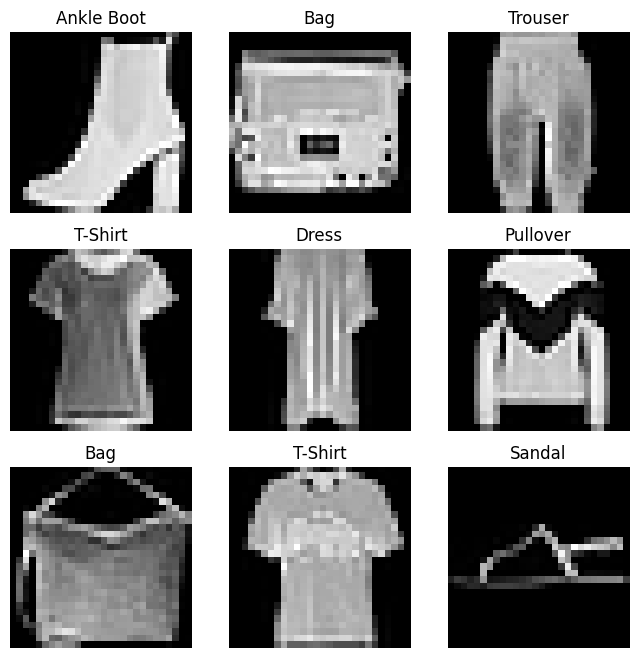

In [39]:
import matplotlib.pyplot as plt

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Creating a custom Dataset for your files

A custom Dataset class must inherit from the `torch.utils.data.Dataset` class and implement three methods:
* `__init__`: it defines all the necessary information for the other methods (e.g., the path of the data, the labels, transforms, etc.)
* `__len_`: it returns the number of samples in our dataset.
* `__getitem__`: loads and returns a sample from the dataset at the given index `idx`.

[Here](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files) is an example from a PyTorch tutorial:

```python
import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset


class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label
```

### Preparing your data for training with DataLoader

The `Dataset` retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in "mini-batches" and reshuffle the data at every epoch to reduce model overfitting.

`DataLoader` is an iterable that abstracts this complexity for us in an easy API.

In [40]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

### Iterate through the DataLoader

We have loaded that dataset into the DataLoader and can iterate through the dataset as needed. Each iteration below returns a batch of `train_features` and `train_labels` (containing `batch_size=64` features and labels respectively). Because we specified `shuffle=True`, after we iterate over all batches, the data is shuffled.

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


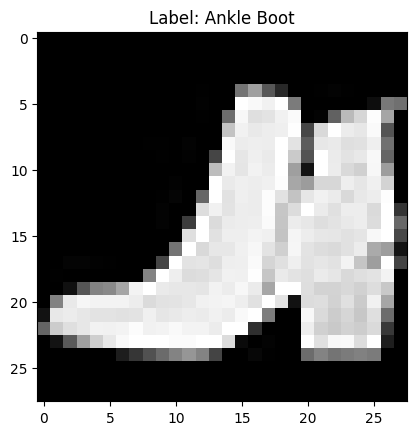

In [ ]:
# Get the next mini-batch of samples
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

# Display the image and the label of the first sample in the mini-batch
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.title(f"Label: {labels_map[label.item()]}")
plt.show()

## Building a neural network

Neural networks comprise of layers/modules that perform operations on data. The [torch.nn](https://pytorch.org/docs/stable/nn.html) namespace provides all the building blocks you need to build your own neural network. Every module in PyTorch subclasses the [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html). A neural network is a module itself that consists of other modules (layers). This nested structure allows for building and managing complex architectures easily.

In the following sections, we’ll build a neural network to classify images in the FashionMNIST dataset.

### Get device for training

We want to be able to train our model on a hardware accelerator like the GPU or MPS, if available. Let’s check to see if [torch.cuda](https://pytorch.org/docs/stable/notes/cuda.html) or [torch.backends.mps](https://pytorch.org/docs/stable/notes/mps.html) are available, otherwise we use the CPU.

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    # else "mps"  # We don't recommend using the MPS backend at this time:
                  # https://github.com/pytorch/pytorch/issues/109457
    # if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


### Define the class (i.e., the architecture)

We define our neural network by subclassing `nn.Module`, and initialize the neural network layers in `__init__`. Every `nn.Module` subclass implements the operations on input data in the `forward` method.

In [ ]:
from torch import nn


class NeralNetworkCustom(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # Convert a 2D array to a 1D array.
        self.linear1 = nn.Linear(28 * 28, 512)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(512, 512)
        self.relu2 = nn.ReLU()
        self.linear3 = nn.Linear(512, 10)

    def forward(self, x):
        y = self.flatten(x)
        y = self.linear1(y)
        y = self.relu1(y)
        y = self.linear2(y)
        y = self.relu2(y)
        y = self.linear3(y)
        return y

In the `__init__` method of the `NeuralNetworkCustom` class, we create layer objects with the `nn.Flatten`, `nn.Linear`, and `nn.ReLu` classes. Then, we define the `forward` method using those layers, to define the forward calculation of our neural network. For this example, we can simplify the implementation using `nn.Sequential` class.

In [ ]:
class NeuralNetworkSimple1(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In the `NeuralNetworkSimple1` class, we wrap the layers with the `nn.Sequential` object. In the forward calculation, we can just call this wrapper object to sequentially apply the mappings defined by the layers. We could further simplify the implementation with inheriting `nn.Sequential`.

In [ ]:
class NeuralNetworkSimple2(nn.Sequential):
    def __init__(self):
        super().__init__(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

NeuralNetwork = NeuralNetworkSimple2

We create an instance of `NeuralNetwork`, and move it to the `device`, and print its structure.

In [ ]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetworkSimple2(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=10, bias=True)
)


To use the model, we pass it the input data. This executes the model's forward, along with some [background operations](https://github.com/pytorch/pytorch/blob/270111b7b611d174967ed204776985cefca9c144/torch/nn/modules/module.py#L866). **Do not call `model.forward()` directly** but use it like a function as `model(X)`.

In [ ]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {labels_map[y_pred.item()]}")

Predicted class: Ankle Boot


### Model parameters

Many layers inside a neural network are parameterized, i.e., have associated weights and biases that are optimized during training. Subclassing `nn.Module` automatically tracks all fields defined inside your model object, and makes all parameters accessible using your model's `parameters()` or `named_parameters()` methods.

In this example, we iterate over all parameters, and print its size and a preview of its values.

In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetworkSimple2(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=10, bias=True)
)


Layer: 1.weight | Size: torch.Size([512, 784]) | Values : tensor([[ 0.0283,  0.0293, -0.0178,  ..., -0.0154,  0.0227, -0.0143],
        [-0.0320, -0.0342,  0.0329,  ..., -0.0166, -0.0301,  0.0317]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: 1.bias | Size: torch.Size([512]) | Values : tensor([ 1.0788e-02, -4.1766e-05], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: 3.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0239, -0.0245, -0.0234,  ...,  0.0411, -0.0054, -0.0293],
        [ 0.0074,  0.0342, -0.0254,  ...,  0.0359,  0.0245,  0.0001]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: 3.bias | Size: torch.Size([512]) | Values : tensor([-0.0086, -0.0407],

## Optimizing the parameters of the model

Now that we have a model and data, we can train, validate, and test our model by optimizing its parameters on our data. Training a model is an iterative process; in each iteration, the model outputs a guess about the true label, calculates the error (or the loss) in its guess, collects the derivatives of the error with respect to its parameters (as we saw in the previous section), and optimizes these parameters using gradient descent.

### Hyperparameters
Hyperparameters are fixed parameters that are not optimized during training, but you can adjust them to control the model class and the optimization process before the training. Different hyperparameter values can impact model training and convergence rates.

We define the following hyperparameters for training:
* **Number of epochs** - the number of times to iterate over the dataset.
* **Batch size** - the number of data samples propagated through the network before the parameters are updated.
* **Learning rate** - how much to update models parameters at each batch/epoch. Smaller values yield slow learning speed, while large values may result in unpredictable behavior during training.

In [ ]:
learning_rate = 1e-3
batch_size = 64
epochs = 10

### Optimization Loop

Once we set our hyperparameters, we can then train and optimize our model with an optimization loop. Each iteration of the optimization loop is called an **epoch**.

Each epoch consists of two main parts:
* The **train loop** - iterate over the training dataset (i.e., for 1 epoch) and to update parameters.
* The **validation/test loop** - iterate over the test dataset to check if model performance is improving.

Let’s briefly familiarize ourselves with some of the concepts used in the training loop.

#### Loss function

When presented with some training data, our untrained network is likely not to give the correct answer. The loss function measures the degree of dissimilarity of obtained result to the target value, and it is the loss function that we want to minimize during training. To calculate the loss we make a prediction using the inputs of our given data sample and compare it against the true data label value.

Common loss functions include [nn.MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss) (Mean Square Error) for regression tasks, and [nn.NLLLoss](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html#torch.nn.NLLLoss) (Negative Log Likelihood) for classification. [nn.CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss) combines `nn.LogSoftmax` and `nn.NLLLoss`.

We pass our model's output to `nn.CrossEntropyLoss`, which will compute the prediction loss.

In [ ]:
loss_fn_mean = nn.CrossEntropyLoss(reduction='mean')
loss_fn_sum = nn.CrossEntropyLoss(reduction='sum')

#### Optimizer

Optimization is the process of adjusting model parameters to reduce model error in each training step. Optimization algorithms define how this process is performed (in this example, we are going to use Stochastic Gradient Descent). All optimization logic is encapsulated in the optimizer object. Here, we use the SGD optimizer; additionally, there are many [different optimizers](https://pytorch.org/docs/stable/optim.html) available in PyTorch.

We initialize the optimizer by registering the model's parameters to be trained as well as the learning rate.

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Inside the training loop, optimization happens in three steps:

* **Important**: Call `optimizer.zero_grad()` to reset the gradients of model parameters. Gradients by default gets accumulated over time; to prevent double-counting, we explicitly zero them at each iteration.
* Backpropagate the prediction loss with a call to `loss.backward()`. PyTorch deposits the gradients of the loss w.r.t. each parameter.
* Once we have our gradients, we call `optimizer.step()` to adjust the parameters by the gradients collected in the backward pass.

#### Full implementation

In [ ]:
def train_1epoch(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)

    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Display loss from time to time
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss: >7f}  [{current: >5d} / {size: >5d}]")


def evaluate(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"\nTest set: \n  Accuracy: {(100 * correct): >0.1f}%, Avg loss: {test_loss: >8f} \n")

In [ ]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_1epoch(train_dataloader, model, loss_fn_mean, optimizer, device)
    evaluate(test_dataloader, model, loss_fn_sum, device)

print("Done!")

Epoch 1
-------------------------------
loss: 2.298965  [   64 / 60000]
loss: 2.283990  [ 6464 / 60000]
loss: 2.269361  [12864 / 60000]
loss: 2.248504  [19264 / 60000]
loss: 2.244971  [25664 / 60000]
loss: 2.210608  [32064 / 60000]
loss: 2.200661  [38464 / 60000]
loss: 2.204318  [44864 / 60000]
loss: 2.207563  [51264 / 60000]
loss: 2.149211  [57664 / 60000]

Test set: 
  Accuracy: 48.4%, Avg loss: 137.388910 

Epoch 2
-------------------------------
loss: 2.164488  [   64 / 60000]
loss: 2.162323  [ 6464 / 60000]
loss: 2.164284  [12864 / 60000]
loss: 2.072637  [19264 / 60000]
loss: 2.116098  [25664 / 60000]
loss: 2.038674  [32064 / 60000]
loss: 2.029724  [38464 / 60000]
loss: 1.992058  [44864 / 60000]
loss: 1.978731  [51264 / 60000]
loss: 1.898239  [57664 / 60000]

Test set: 
  Accuracy: 59.2%, Avg loss: 121.536592 

Epoch 3
-------------------------------
loss: 1.910290  [   64 / 60000]
loss: 1.885237  [ 6464 / 60000]
loss: 1.790972  [12864 / 60000]
loss: 1.829061  [19264 / 60000]
loss